# 🧩 Кластеризация: сравнение методов

В этом ноутбуке мы протестируем разные методы кластеризации и сравним их результаты с помощью метрик и визуализации.

## Содержание
1. Импорт библиотек
2. Генерация синтетического датасета
3. Визуализация данных
4. Кластеризация: KMeans, DBSCAN, Agglomerative, GaussianMixture
5. Метрики качества кластеризации
6. Сравнительная таблица и визуализация результатов

In [1]:
# 1. Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import seaborn as sns
sns.set(style='whitegrid')

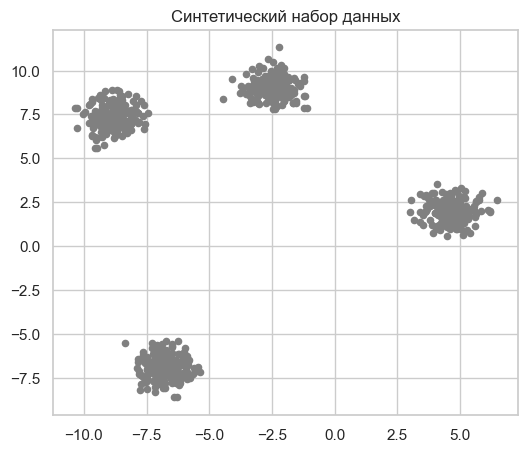

In [2]:
# 2. Генерация синтетического датасета

# Попробуйте другие варианты: 'blobs' или 'moons'
dataset_type = 'blobs'  # или 'moons'

if dataset_type == 'blobs':
    X, y_true = make_blobs(n_samples=800, centers=4, cluster_std=0.60, random_state=42)
elif dataset_type == 'moons':
    X, y_true = make_moons(n_samples=800, noise=0.07, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=20, c='gray')
plt.title('Синтетический набор данных')
plt.show()

D:\conda\envs\gz\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\conda\envs\gz\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


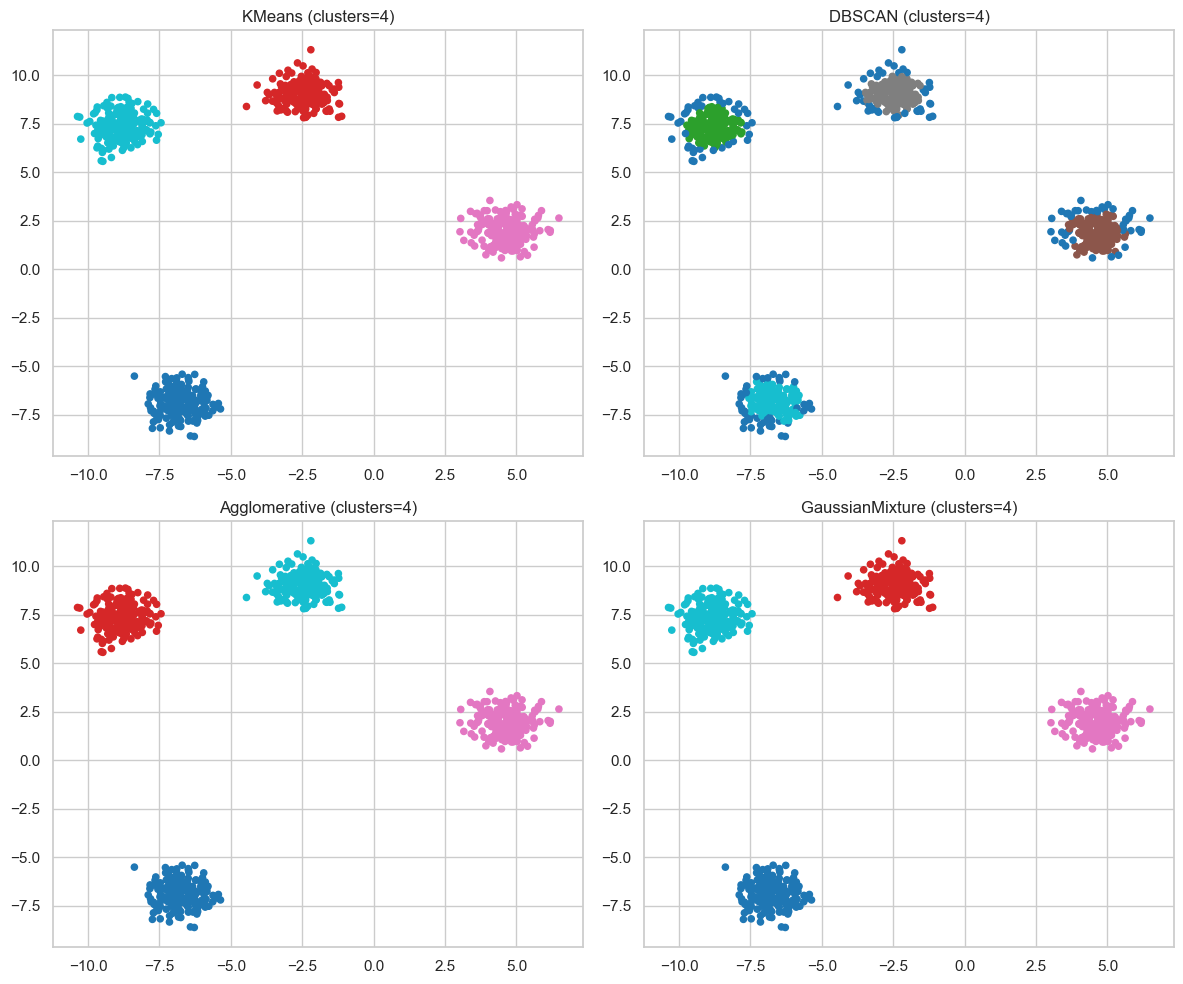

In [3]:
# 3. Применение разных методов кластеризации

models = {
    'KMeans': KMeans(n_clusters=4, random_state=42),
    'DBSCAN': DBSCAN(eps=0.3, min_samples=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=4),
    'GaussianMixture': GaussianMixture(n_components=4, random_state=42)
}

results = []

plt.figure(figsize=(12, 10))

for i, (name, model) in enumerate(models.items(), 1):
    if name == 'GaussianMixture':
        labels = model.fit_predict(X)
    else:
        labels = model.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Метрики
    if n_clusters > 1:
        silhouette = silhouette_score(X, labels)
        calinski = calinski_harabasz_score(X, labels)
        davies = davies_bouldin_score(X, labels)
    else:
        silhouette = calinski = davies = np.nan

    results.append([name, n_clusters, silhouette, calinski, davies])

    plt.subplot(2, 2, i)
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='tab10')
    plt.title(f"{name} (clusters={n_clusters})")

plt.tight_layout()
plt.show()

In [4]:
# 4. Таблица с результатами метрик
df_results = pd.DataFrame(results, columns=['Model', 'Clusters', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin'])
df_results.set_index('Model', inplace=True)
df_results.round(3)

,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
Model,,,,
KMeans,4,0.874,24294.487,0.177
DBSCAN,4,0.515,642.987,1.177
Agglomerative,4,0.874,24294.487,0.177
GaussianMixture,4,0.874,24294.487,0.177


D:\conda\envs\gz\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


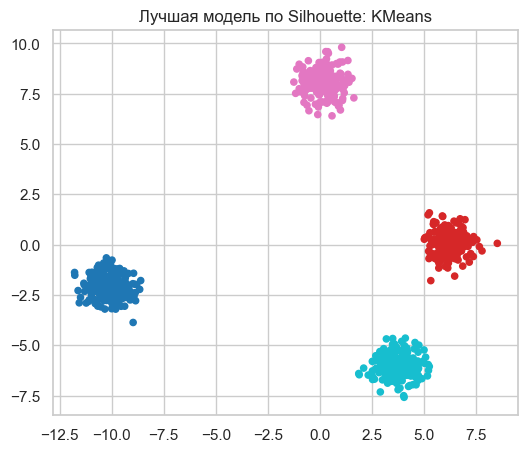

In [5]:
# 5. Визуализация в пространстве PCA (если данных > 2D)
pca = PCA(n_components=2)
Xp = pca.fit_transform(X)

best_model_name = df_results['Silhouette'].idxmax()
best_model = models[best_model_name]
labels_best = best_model.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(Xp[:, 0], Xp[:, 1], c=labels_best, cmap='tab10', s=20)
plt.title(f'Лучшая модель по Silhouette: {best_model_name}')
plt.show()

### ✅ Заключение
- **KMeans** хорошо работает на изолированных сферических кластерах.
- **DBSCAN** находит кластеры произвольной формы и отсекает шум.
- **Agglomerative** позволяет гибко выбирать метрику расстояния и критерий слияния.
- **Gaussian Mixture** подходит, если кластеры имеют гауссовскую природу.

Можно поэкспериментировать с параметрами `eps`, `n_clusters`, `cluster_std`, а также попробовать другие наборы данных.

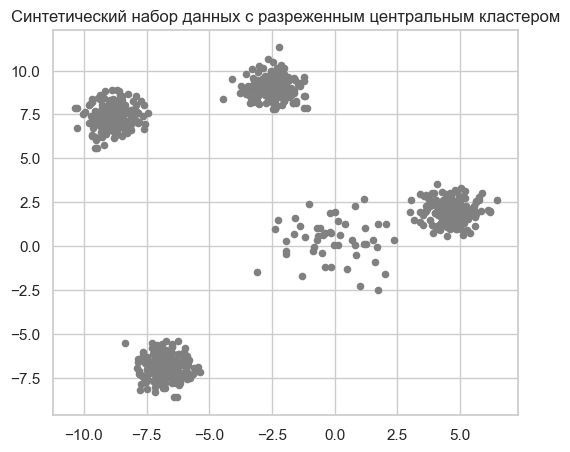

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
import numpy as np

dataset_type = 'blobs'  # или 'moons'

if dataset_type == 'blobs':
    # Основные кластеры
    X, y_true = make_blobs(n_samples=800, centers=4, cluster_std=0.60, random_state=42)
    
    # Добавляем разреженный кластер в центр
    X_center, y_center = make_blobs(n_samples=50, centers=[[0,0]], cluster_std=1.2, random_state=24)
    
    # Объединяем
    X = np.vstack([X, X_center])
    y_true = np.hstack([y_true, [4]*len(y_center)])  # присваиваем новый лейбл 4

elif dataset_type == 'moons':
    X, y_true = make_moons(n_samples=800, noise=0.07, random_state=42)
    # Для moons можно добавить небольшой случайный кластер в центр
    X_center = np.random.normal(loc=[0,0], scale=0.5, size=(50,2))
    X = np.vstack([X, X_center])
    y_true = np.hstack([y_true, [2]*len(X_center)])  # новый лейбл 2

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=20, c='gray')
plt.title('Синтетический набор данных с разреженным центральным кластером')
plt.show()


D:\conda\envs\gz\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\conda\envs\gz\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


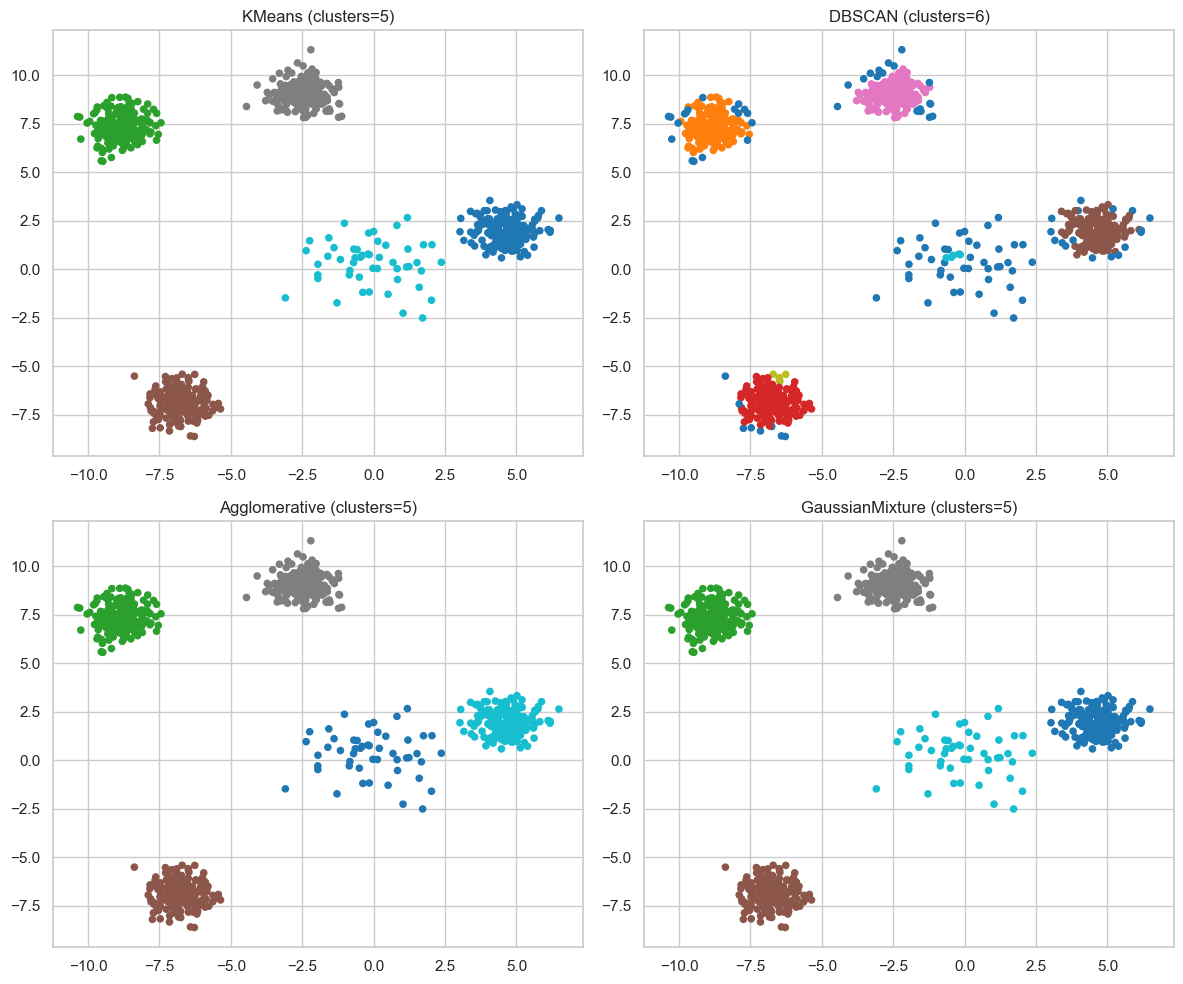

In [8]:
# 3. Применение разных методов кластеризации

models = {
    'KMeans': KMeans(n_clusters=5, random_state=42),
    'DBSCAN': DBSCAN(eps=0.3, min_samples=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=5),
    'GaussianMixture': GaussianMixture(n_components=5,random_state=42)
}

results = []

plt.figure(figsize=(12, 10))

for i, (name, model) in enumerate(models.items(), 1):
    if name == 'GaussianMixture':
        labels = model.fit_predict(X)
    else:
        labels = model.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Метрики
    if n_clusters > 1:
        silhouette = silhouette_score(X, labels)
        calinski = calinski_harabasz_score(X, labels)
        davies = davies_bouldin_score(X, labels)
    else:
        silhouette = calinski = davies = np.nan

    results.append([name, n_clusters, silhouette, calinski, davies])

    plt.subplot(2, 2, i)
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='tab10')
    plt.title(f"{name} (clusters={n_clusters})")

plt.tight_layout()
plt.show()